In [5]:
import requests

from datetime import date, timedelta

def fetch_doaj_by_date(topic, start_date, end_date, page_size=100, max_pages=10):
    all_results = []
    for page in range(1, max_pages + 1):
        url = (
            f"https://doaj.org/api/v2/search/articles/{topic}"
            f"?pageSize={page_size}&page={page}"
            f"&fromDate={start_date.strftime('%Y-%m-%d')}"
            f"&toDate={end_date.strftime('%Y-%m-%d')}"
        )
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            results = data.get("results", [])
            if not results:
                break
            all_results.extend(results)
        else:
            print(f"Failed to fetch data (status={response.status_code}) for range {start_date}-{end_date}, page={page}")
            break
    return all_results

def fetch_doaj_by_months(topic, start_year=2020, end_year=2021):
    all_results = []

    current_date = date(start_year, 1, 1)
    final_date = date(end_year+1, 1, 1)
    while current_date < final_date:
        if current_date.month == 12:
            next_month = date(current_date.year + 1, 1, 1)
        else:
            next_month = date(current_date.year, current_date.month + 1, 1)

        slice_results = fetch_doaj_by_date(topic, current_date, next_month)
        print(f"{topic} for {current_date} to {next_month}: fetched {len(slice_results)}")
        all_results.extend(slice_results)

        current_date = next_month

    return all_results

topics = ["taxation", "technology", "economic growth"]

all_papers_sliced = []

for t in topics:
    papers_for_t = fetch_doaj_by_months(t, start_year=2020, end_year=2025)
    print(f"{t}: total {len(papers_for_t)} papers from 2020–2025.")
    all_papers_sliced.extend(papers_for_t)

print(f"Grand total for all topics: {len(all_papers_sliced)}")

taxation for 2020-01-01 to 2020-02-01: fetched 1000
taxation for 2020-02-01 to 2020-03-01: fetched 1000
taxation for 2020-03-01 to 2020-04-01: fetched 1000
taxation for 2020-04-01 to 2020-05-01: fetched 1000
taxation for 2020-05-01 to 2020-06-01: fetched 1000
taxation for 2020-06-01 to 2020-07-01: fetched 1000
taxation for 2020-07-01 to 2020-08-01: fetched 1000
taxation for 2020-08-01 to 2020-09-01: fetched 1000
taxation for 2020-09-01 to 2020-10-01: fetched 1000
taxation for 2020-10-01 to 2020-11-01: fetched 1000
taxation for 2020-11-01 to 2020-12-01: fetched 1000
taxation for 2020-12-01 to 2021-01-01: fetched 1000
taxation for 2021-01-01 to 2021-02-01: fetched 1000
taxation for 2021-02-01 to 2021-03-01: fetched 1000
taxation for 2021-03-01 to 2021-04-01: fetched 1000
taxation for 2021-04-01 to 2021-05-01: fetched 1000
taxation for 2021-05-01 to 2021-06-01: fetched 1000
taxation for 2021-06-01 to 2021-07-01: fetched 1000
taxation for 2021-07-01 to 2021-08-01: fetched 1000
taxation for

In [6]:
print(all_papers_sliced[:5])

[{'last_updated': '2022-12-21T22:45:26Z', 'bibjson': {'identifier': [{'id': 'https://doi.org/10.1344/jesb2021.2.j092', 'type': 'doi'}, {'id': '2385-7137', 'type': 'pissn'}, {'id': '2385-7137', 'type': 'eissn'}], 'journal': {'volume': '6', 'number': '2', 'country': 'ES', 'issns': ['2385-7137'], 'publisher': 'Universitat de Barcelona', 'language': ['EN'], 'title': 'Journal of Evolutionary Studies in Business'}, 'month': '7', 'end_page': '86', 'keywords': ['british business groups', 'river plate trust', 'financial firms', 'mortgage companies', 'public utilities', 'foreign investment', 'argentina', 'uruguay'], 'year': '2021', 'start_page': '42', 'subject': [{'code': 'HF5001-6182', 'scheme': 'LCC', 'term': 'Business'}], 'author': [{'orcid_id': 'https://orcid.org/0000-0002-0185-3166', 'affiliation': 'Universidad Nacional de Rosario / CONICET ', 'name': 'Norma Silvana Lanciotti'}], 'link': [{'type': 'fulltext', 'url': 'https://revistes.ub.edu/index.php/JESB/article/view/j092'}], 'abstract': '

In [8]:
import csv

with open(r"C:\Users\Lina\Documents\application\2024\Lund_edu\Deep Learning\final project\doaj.csv", "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["id", "title", "year", "month", "abstract", "authors", "journal", "keywords"])
    for article in all_papers_sliced:
        bibjson = article.get("bibjson", {})
        writer.writerow([
            article.get("id", ""),
            bibjson.get("title", ""),
            bibjson.get("year", ""),
            bibjson.get("month", ""),
            bibjson.get("abstract", ""),
            ", ".join([author.get("name", "") for author in bibjson.get("author", [])]),
            bibjson.get("journal", {}).get("title", ""),
            ", ".join(bibjson.get("keywords", []))
        ])

print("C:\\Users\\Lina\\Documents\\application\\2024\\Lund_edu\\Deep Learning\\final project\\doaj.csv")

C:\Users\Lina\Documents\application\2024\Lund_edu\Deep Learning\final project\doaj.csv


In [14]:
import re
import requests
import pandas as pd
import numpy as np
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
#updated
papers = all_papers_sliced

abstracts = []
keywords = []
for paper in papers:
    if 'bibjson' in paper and 'abstract' in paper['bibjson'] and 'keywords' in paper['bibjson']:
        abstracts.append(paper['bibjson']['abstract'])
        keywords.append(paper['bibjson']['keywords'])

counts = Counter()
for kw_list in keywords:
    for kw in kw_list:
        counts[kw] += 1

threshold = 100
valid_keywords = {kw for kw, freq in counts.items() if freq > threshold}
print(f"Keywords above threshold {threshold}: {len(valid_keywords)}")

filtered_abstracts = []
filtered_keywords = []

for abs_text, kw_list in zip(abstracts, keywords):
    kw_filtered = [kw for kw in kw_list if kw in valid_keywords]
    if kw_filtered:
        filtered_abstracts.append(abs_text)
        filtered_keywords.append(kw_filtered)

print(f"Kept {len(filtered_abstracts)} articles out of {len(abstracts)} total.")

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

abstracts = [preprocess_text(a) for a in filtered_abstracts]

keywords = [[preprocess_text(kw) for kw in kw_list] for kw_list in filtered_keywords]

unique_keywords = set()
for kw_list in keywords:
    unique_keywords.update(kw_list)
unique_keywords = list(unique_keywords)
num_keywords = len(unique_keywords)

kw_to_idx = {kw: i for i, kw in enumerate(unique_keywords)}

num_papers = len(abstracts)
Y = np.zeros((num_papers, num_keywords), dtype=np.int32)
for i, kw_list in enumerate(keywords):
    for kw in kw_list:
        if kw in kw_to_idx:
            Y[i, kw_to_idx[kw]] = 1

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(abstracts)
X = tokenizer.texts_to_sequences(abstracts)

max_len = 20
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=208
)

print(f"Vocabulary size: {vocab_size}")
print(f"Number of unique keywords: {num_keywords}")

Keywords above threshold 100: 801
Kept 96120 articles out of 172008 total.
Vocabulary size: 20718
Number of unique keywords: 729


In [16]:
for kw_list in keywords:
    for kw in kw_list:
        counts[kw] += 1

top_10 = counts.most_common(10)
print("Top 10 keywords by frequency:")
for kw, freq in top_10:
    print(f"{kw}: {freq}")

Top 10 keywords by frequency:
taxation: 13032
economic growth: 10152
tax: 3960
taxes: 3312
tax system: 3168
sustainable development: 2520
economic development: 2304
machine learning: 2304
competitiveness: 2160
artificial intelligence: 1944


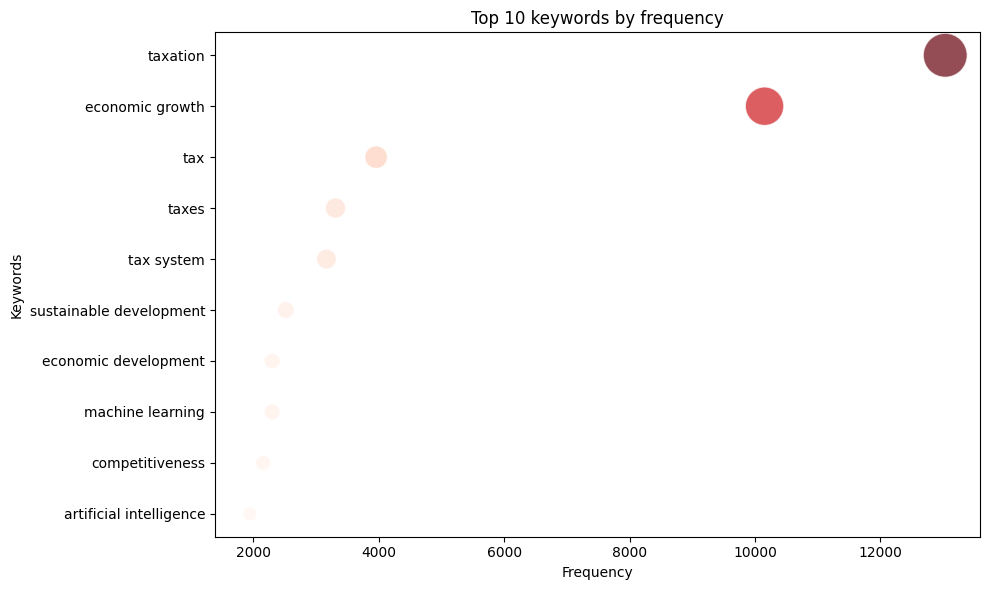

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

keywords = [kw for kw, freq in top_10]
frequencies = [freq for kw, freq in top_10]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=frequencies,
    y=keywords,
    size=frequencies,
    sizes=(100, 1000),
    alpha=0.7,
    hue=frequencies,
    palette="Reds",
    legend=False
)

plt.xlabel("Frequency")
plt.ylabel("Keywords")
plt.title("Top 10 keywords by frequency")
plt.tight_layout()

plt.savefig("top_10_keywords_bubble.png")
plt.show()

In [19]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

abstracts = [preprocess_text(a) for a in abstracts]

keywords = [[preprocess_text(kw) for kw in kw_list] for kw_list in keywords]

unique_keywords = set()
for kw_list in keywords:
    unique_keywords.update(kw_list)
unique_keywords = list(unique_keywords)
num_keywords = len(unique_keywords)

kw_to_idx = {kw: i for i, kw in enumerate(unique_keywords)}
num_papers = len(abstracts)
Y = np.zeros((num_papers, num_keywords), dtype=np.int32)
for i, kw_list in enumerate(keywords):
    for kw in kw_list:
        if kw in kw_to_idx:
            Y[i, kw_to_idx[kw]] = 1

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(abstracts)
X = tokenizer.texts_to_sequences(abstracts)

max_len = 20
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=208
)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 128, input_length=max_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.2)]
)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)


loss, bin_acc = model.evaluate(X_test, y_test)
print("Binary Accuracy:", bin_acc, "Loss:", loss)


def predict_keywords(text):
    text_clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    probs = model.predict(padded)[0]

    indices = [i for i, p in enumerate(probs) if p >= 0.2]
    return [unique_keywords[i] for i in indices]

test_text = "Discussion about taxation, growth, and technology trends."
predicted = predict_keywords(test_text)
print("Predicted Keywords:", predicted)

Epoch 1/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - binary_accuracy: 0.8628 - loss: 0.0922 - val_binary_accuracy: 1.0000 - val_loss: 4.0332e-04
Epoch 2/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - binary_accuracy: 0.9999 - loss: 8.3431e-04 - val_binary_accuracy: 1.0000 - val_loss: 3.9889e-04
Epoch 3/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 46s 95ms/step - binary_accuracy: 1.0000 - loss: 1.9901e-04 - val_binary_accuracy: 1.0000 - val_loss: 3.9650e-04
Epoch 4/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 46s 95ms/step - binary_accuracy: 1.0000 - loss: 4.7943e-04 - val_binary_accuracy: 1.0000 - val_loss: 3.8147e-04
Epoch 5/5
481/481 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - binary_accuracy: 1.0000 - loss: 4.4905e-04 - val_binary_accuracy: 1.0000 - val_loss: 3.9274e-04
601/601 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - binary_accuracy: 1.0000 - loss: 1.1246e-04
Binary Accuracy: 0.9999619126319885 Loss: 0.00045485299779102206
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
Predicted Keywords: []


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 20, 128)             │       2,651,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 20, 256)             │         198,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │         123,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,948,783 (34.14 MB)

 Trainable params: 2,982,927 (11.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,965,856 (22.76 MB)

In [26]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 128, input_length=max_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(128, return_sequences=True, kernel_regularizer=l2(0.01))),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64, kernel_regularizer=l2(0.01))),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.2)]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - binary_accuracy: 0.8323 - loss: 2.2363 - val_binary_accuracy: 1.0000 - val_loss: 0.0034
Epoch 2/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 47s 98ms/step - binary_accuracy: 1.0000 - loss: 0.0036 - val_binary_accuracy: 1.0000 - val_loss: 0.0029
Epoch 3/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - binary_accuracy: 0.9999 - loss: 0.0030 - val_binary_accuracy: 1.0000 - val_loss: 0.0011


In [27]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 20, 128)             │       2,651,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_12 (Bidirectional)     │ (None, 20, 256)             │         198,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 20, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_13 (Bidirectional)     │ (None, 128)                 │         123,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,948,783 (34.14 MB)

 Trainable params: 2,982,927 (11.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,965,856 (22.76 MB)

In [29]:
loss, binary_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Binary Accuracy: {binary_accuracy}")

601/601 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - binary_accuracy: 1.0000 - loss: 8.7015e-04
Test Loss: 0.0011733837891370058
Test Binary Accuracy: 0.9999619126319885


In [30]:
unseen_abstracts = ["Example abstract about taxation and technology.",
                    "Another abstract discussing economic growth."]
unseen_keywords = [["taxation", "technology"], ["economic growth"]]

unseen_abstracts_preprocessed = [preprocess_text(a) for a in unseen_abstracts]

unseen_keywords_binary = []
for kw_list in unseen_keywords:
    binary_label = [0] * len(unique_keywords)
    for kw in kw_list:
        if kw in kw_to_idx:
            binary_label[kw_to_idx[kw]] = 1
    unseen_keywords_binary.append(binary_label)

X_unseen = tokenizer.texts_to_sequences(unseen_abstracts_preprocessed)
X_unseen = pad_sequences(X_unseen, maxlen=max_len, padding='post', truncating='post')
y_unseen = np.array(unseen_keywords_binary)

loss, binary_accuracy = model.evaluate(X_unseen, y_unseen)
print(f"Unseen Test Loss: {loss}")
print(f"Unseen Test Binary Accuracy: {binary_accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - binary_accuracy: 1.0000 - loss: 7.9273e-04
Unseen Test Loss: 0.0007927250699140131
Unseen Test Binary Accuracy: 1.0


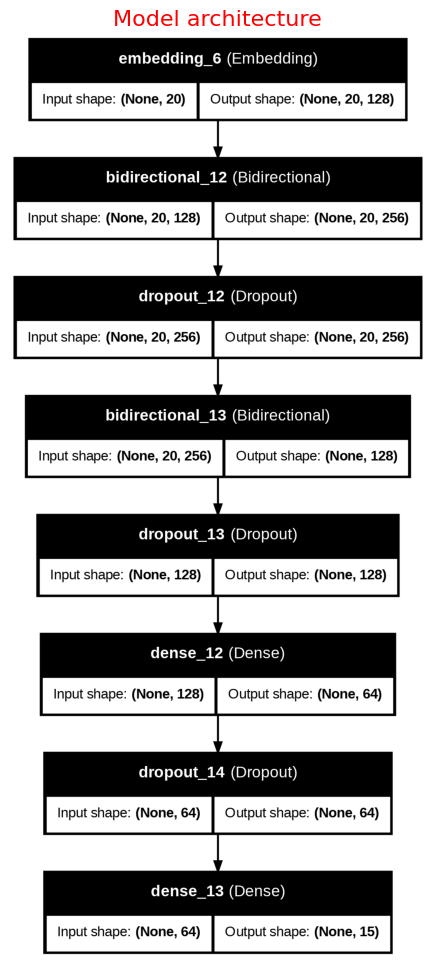

In [28]:
import tensorflow as tf
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000)
tokenizer.fit_on_texts(abstracts)
vocab_size = len(tokenizer.word_index) + 1
max_len = max(len(seq) for seq in tokenizer.texts_to_sequences(abstracts))

mlb = MultiLabelBinarizer()
binary_keywords = mlb.fit_transform(keywords)
num_keywords = len(mlb.classes_)

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

sns.set_theme(style="whitegrid", palette="Reds")
img = plt.imread('model_architecture.png')

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.title("Model architecture", fontsize=16, color='red')
plt.show()

In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.2)]
)

history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


481/481 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - binary_accuracy: 0.7308 - loss: 0.1766 - val_binary_accuracy: 1.0000 - val_loss: 0.0026
Epoch 2/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - binary_accuracy: 1.0000 - loss: 0.0021 - val_binary_accuracy: 1.0000 - val_loss: 0.0011
Epoch 3/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - binary_accuracy: 0.9999 - loss: 0.0012 - val_binary_accuracy: 1.0000 - val_loss: 6.9748e-04


In [32]:
loss, binary_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Binary Accuracy: {binary_accuracy}")

601/601 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 1.0000 - loss: 4.8466e-04
Test Loss: 0.0007233246578834951
Test Binary Accuracy: 0.9999619126319885


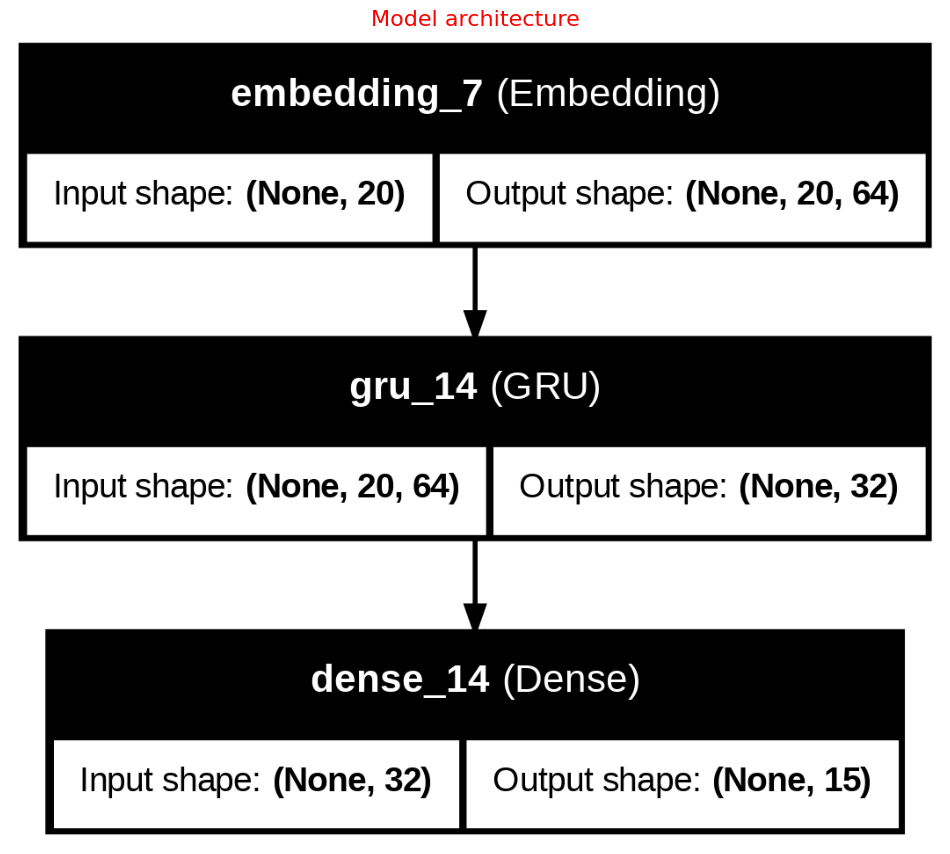

In [33]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000)
tokenizer.fit_on_texts(abstracts)
vocab_size = len(tokenizer.word_index) + 1
max_len = max(len(seq) for seq in tokenizer.texts_to_sequences(abstracts))

mlb = MultiLabelBinarizer()
binary_keywords = mlb.fit_transform(keywords)
num_keywords = len(mlb.classes_)

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

sns.set_theme(style="whitegrid", palette="Reds")
img = plt.imread('model_architecture.png')

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.title("Model architecture", fontsize=16, color='red')
plt.show()

In [34]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 20, 64)              │       1,325,888 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_14 (GRU)                         │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 15)                  │             495 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,007,375 (15.29 MB)

 Trainable params: 1,335,791 (5.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,671,584 (10.19 MB)

In [36]:
import numpy as np

X_train_noisy = X_train + np.random.normal(0, 0.1, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 0.1, X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0, vocab_size - 1)
X_test_noisy = np.clip(X_test_noisy, 0, vocab_size - 1)

history = model.fit(
    X_train_noisy, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

loss, binary_accuracy = model.evaluate(X_test_noisy, y_test)
print(f"Test Loss: {loss}")
print(f"Test Binary Accuracy: {binary_accuracy}")

Epoch 1/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 1.0000 - loss: 4.7999e-04 - val_binary_accuracy: 1.0000 - val_loss: 4.8094e-04
Epoch 2/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 1.0000 - loss: 5.2490e-04 - val_binary_accuracy: 1.0000 - val_loss: 4.4169e-04
Epoch 3/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 1.0000 - loss: 5.4720e-04 - val_binary_accuracy: 1.0000 - val_loss: 4.1905e-04
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 1.0000 - loss: 1.7140e-04
Test Loss: 0.0004519330395851284
Test Binary Accuracy: 0.9999619126319885


In [39]:
noise = np.random.binomial(1, 0.13, y_train.shape)  # noise
y_train_noisy = np.clip(y_train + noise, 0, 1)

history = model.fit(
    X_train, y_train_noisy,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

loss, binary_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Binary Accuracy: {binary_accuracy}")

Epoch 1/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 0.8497 - loss: 0.3899 - val_binary_accuracy: 0.8707 - val_loss: 0.3856
Epoch 2/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 0.8700 - loss: 0.3859 - val_binary_accuracy: 0.8707 - val_loss: 0.3857
Epoch 3/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 0.8692 - loss: 0.3865 - val_binary_accuracy: 0.8702 - val_loss: 0.3864
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9992 - loss: 0.1394
Test Loss: 0.1394171267747879
Test Binary Accuracy: 0.9992200136184692


In [44]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
)

history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - binary_accuracy: 0.7543 - loss: 0.1808 - val_binary_accuracy: 1.0000 - val_loss: 0.0027
Epoch 2/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - binary_accuracy: 1.0000 - loss: 0.0020 - val_binary_accuracy: 1.0000 - val_loss: 0.0011
Epoch 3/3
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - binary_accuracy: 1.0000 - loss: 0.0010 - val_binary_accuracy: 1.0000 - val_loss: 7.2282e-04


In [47]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
)

history = model.fit(
    X_train, y_train,
    epochs=1,
    batch_size=128,
    validation_split=0.2
)

481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - binary_accuracy: 0.7415 - loss: 0.1839 - val_binary_accuracy: 1.0000 - val_loss: 0.0022


In [48]:
from tensorflow.keras.optimizers import Adam

custom_adam = Adam(
    learning_rate=0.0005,  # Lower learning rate
    beta_1=0.8,           # Adjust momentum
    beta_2=0.95,          # Adjust RMSProp-like behavior
    epsilon=1e-8,         # Change epsilon value
    amsgrad=True          # Use AMSGrad variant
)

model.compile(
    optimizer=custom_adam,
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
)

history = model.fit(
    X_train, y_train,
    epochs=1,
    batch_size=128,
    validation_split=0.2
)

481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - binary_accuracy: 1.0000 - loss: 0.0010 - val_binary_accuracy: 1.0000 - val_loss: 4.8695e-04


In [49]:
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

optimizers = {
    "Adam": Adam(learning_rate=0.001),
    "Adam2": Adam(learning_rate=0.0001),
    "Adam3": Adam(learning_rate=0.00001),
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adagrad": Adagrad(learning_rate=0.01)
}

results = []

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name} optimizer...")

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
        tf.keras.layers.GRU(32),
        tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
    )

    history = model.fit(
        X_train, y_train,
        epochs=1,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    val_loss = history.history['val_loss'][-1]
    val_accuracy = history.history['val_binary_accuracy'][-1]

    results.append({
        "Optimizer": opt_name,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

Training with Adam optimizer...
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - binary_accuracy: 0.7316 - loss: 0.1933 - val_binary_accuracy: 1.0000 - val_loss: 0.0025
Training with Adam2 optimizer...
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - binary_accuracy: 0.1971 - loss: 0.5478 - val_binary_accuracy: 1.0000 - val_loss: 0.0683
Training with Adam3 optimizer...
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - binary_accuracy: 2.8135e-05 - loss: 0.6896 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.6763
Training with SGD optimizer...
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - binary_accuracy: 0.5298 - loss: 0.3342 - val_binary_accuracy: 1.0000 - val_loss: 0.0136
Training with RMSprop optimizer...
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - binary_accuracy: 0.7776 - loss: 0.1597 - val_binary_accuracy: 1.0000 - val_loss: 6.9979e-04
Training with Adagrad optimizer...
481/481 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - binary_accuracy: 0.1139 - loss: 0.5521 - val_binary_accuracy: 1.0000 - val_loss: 0.11

<ipython-input-57-fca9ffe83fef>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')


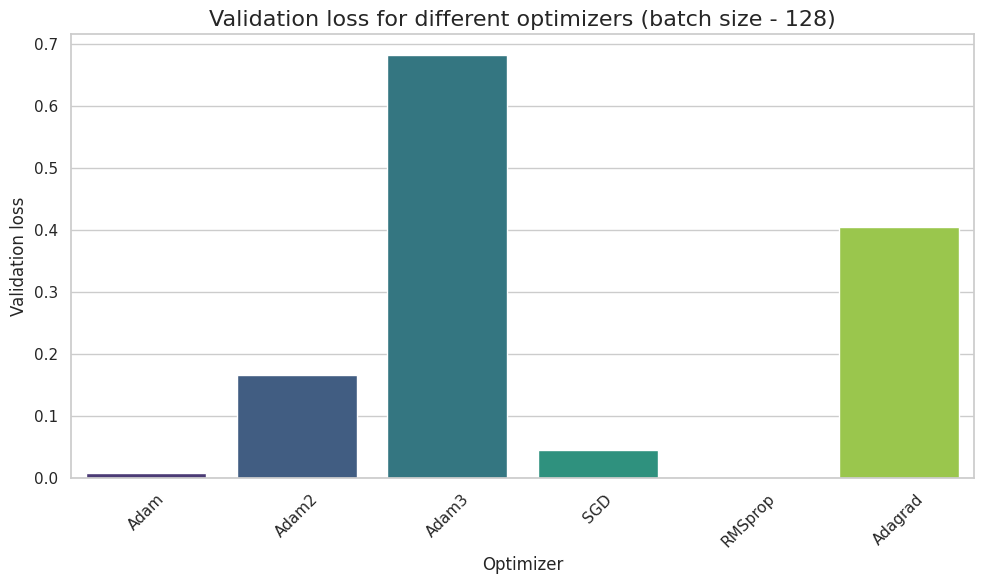

<ipython-input-57-fca9ffe83fef>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')


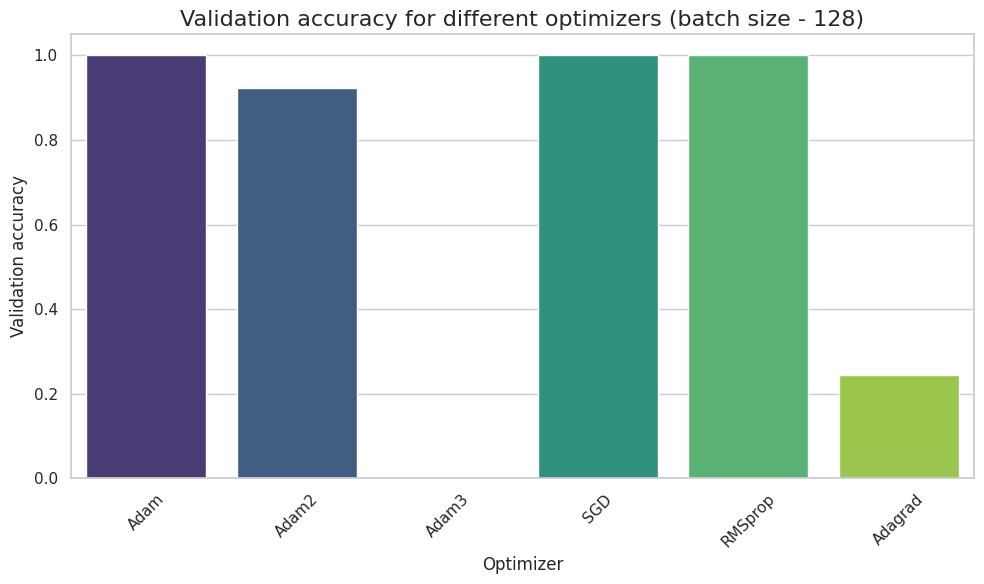

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

results_df['Optimizer'] = results_df['Optimizer'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')
plt.title('Validation loss for different optimizers (batch size - 128)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation loss', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')
plt.title('Validation accuracy for different optimizers (batch size - 128)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
#different batch size (256)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

optimizers = {
    "Adam": Adam(learning_rate=0.001),
    "Adam2": Adam(learning_rate=0.0001),
    "Adam3": Adam(learning_rate=0.00001),
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adagrad": Adagrad(learning_rate=0.01)
}

results = []

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name} optimizer...")

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
        tf.keras.layers.GRU(32),
        tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
    )

    history = model.fit(
        X_train, y_train,
        epochs=1,
        batch_size=256,
        validation_split=0.2,
        verbose=1
    )

    val_loss = history.history['val_loss'][-1]
    val_accuracy = history.history['val_binary_accuracy'][-1]

    results.append({
        "Optimizer": opt_name,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

Training with Adam optimizer...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - binary_accuracy: 0.5861 - loss: 0.2974 - val_binary_accuracy: 1.0000 - val_loss: 0.0078
Training with Adam2 optimizer...
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - binary_accuracy: 0.0284 - loss: 0.6432 - val_binary_accuracy: 0.9236 - val_loss: 0.1670
Training with Adam3 optimizer...
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - binary_accuracy: 1.7639e-05 - loss: 0.6904 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.6818
Training with SGD optimizer...
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - binary_accuracy: 0.2206 - loss: 0.5087 - val_binary_accuracy: 1.0000 - val_loss: 0.0453
Training with RMSprop optimizer...
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - binary_accuracy: 0.6092 - loss: 0.2773 - val_binary_accuracy: 1.0000 - val_loss: 0.0017
Training with Adagrad optimizer...
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - binary_accuracy: 0.0050 - loss: 0.6182 - val_binary_accuracy: 0.2447 - val_loss: 0.4051
  Optimizer  Validation Loss  Val

<ipython-input-58-ee1db0f3837b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')


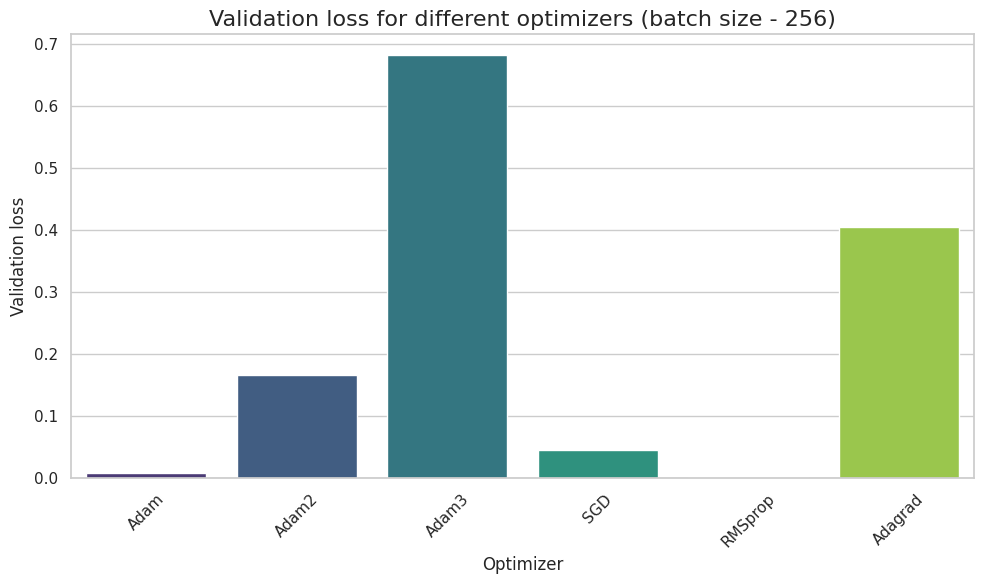

<ipython-input-58-ee1db0f3837b>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')


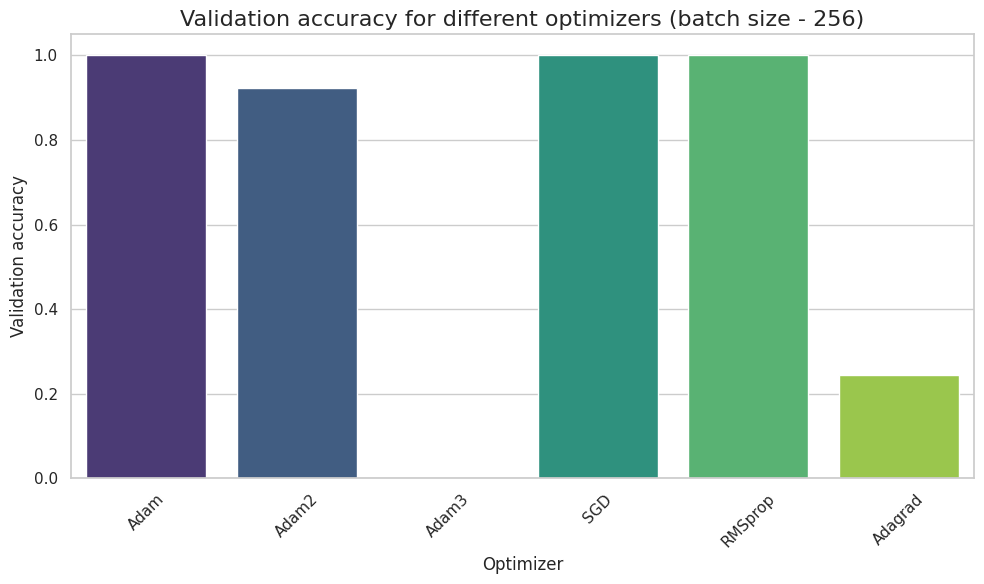

In [58]:
results_df['Optimizer'] = results_df['Optimizer'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')
plt.title('Validation loss for different optimizers (batch size - 256)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation loss', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')
plt.title('Validation accuracy for different optimizers (batch size - 256)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
#different batch size (512)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

optimizers = {
    "Adam": Adam(learning_rate=0.001),
    "Adam2": Adam(learning_rate=0.0001),
    "Adam3": Adam(learning_rate=0.00001),
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adagrad": Adagrad(learning_rate=0.01)
}

results = []

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name} optimizer...")

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
        tf.keras.layers.GRU(32),
        tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
    )

    history = model.fit(
        X_train, y_train,
        epochs=1,
        batch_size=512,
        validation_split=0.2,
        verbose=1
    )

    val_loss = history.history['val_loss'][-1]
    val_accuracy = history.history['val_binary_accuracy'][-1]

    results.append({
        "Optimizer": opt_name,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

Training with Adam optimizer...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - binary_accuracy: 0.3931 - loss: 0.4217 - val_binary_accuracy: 1.0000 - val_loss: 0.0218
Training with Adam2 optimizer...
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - binary_accuracy: 2.0142e-04 - loss: 0.6768 - val_binary_accuracy: 0.0196 - val_loss: 0.5638
Training with Adam3 optimizer...
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - binary_accuracy: 1.7187e-05 - loss: 0.6923 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.6892
Training with SGD optimizer...
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - binary_accuracy: 0.0604 - loss: 0.5938 - val_binary_accuracy: 0.9333 - val_loss: 0.2108
Training with RMSprop optimizer...
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - binary_accuracy: 0.4335 - loss: 0.3902 - val_binary_accuracy: 1.0000 - val_loss: 0.0089
Training with Adagrad optimizer...
121/121 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - binary_accuracy: 1.4692e-05 - loss: 0.6474 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.5244
  Optimizer  Validati

<ipython-input-60-bd99c9c58f86>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')


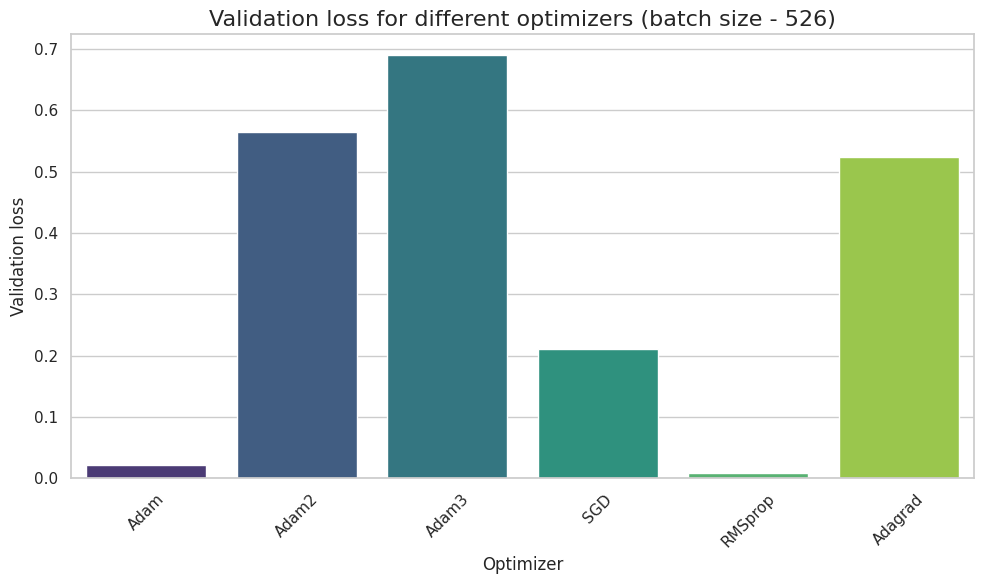

<ipython-input-60-bd99c9c58f86>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')


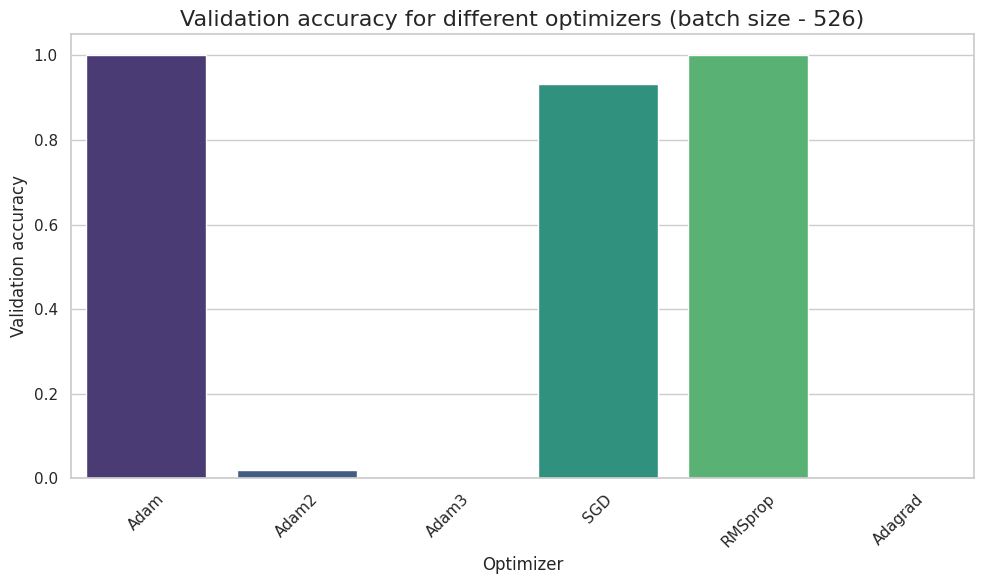

In [60]:
results_df['Optimizer'] = results_df['Optimizer'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')
plt.title('Validation loss for different optimizers (batch size - 526)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation loss', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')
plt.title('Validation accuracy for different optimizers (batch size - 526)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
#different batch size (1024)
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad

optimizers = {
    "Adam": Adam(learning_rate=0.001),
    "Adam2": Adam(learning_rate=0.0001),
    "Adam3": Adam(learning_rate=0.00001),
    "SGD": SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adagrad": Adagrad(learning_rate=0.01)
}

results = []

for opt_name, optimizer in optimizers.items():
    print(f"Training with {opt_name} optimizer...")

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, 64, input_length=max_len),
        tf.keras.layers.GRU(32),
        tf.keras.layers.Dense(num_keywords, activation='sigmoid'),
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.3)]
    )

    history = model.fit(
        X_train, y_train,
        epochs=1,
        batch_size=1024,
        validation_split=0.2,
        verbose=1
    )

    val_loss = history.history['val_loss'][-1]
    val_accuracy = history.history['val_binary_accuracy'][-1]

    results.append({
        "Optimizer": opt_name,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

Training with Adam optimizer...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - binary_accuracy: 0.1851 - loss: 0.5448 - val_binary_accuracy: 1.0000 - val_loss: 0.0552
Training with Adam2 optimizer...
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - binary_accuracy: 4.4533e-05 - loss: 0.6864 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.6589
Training with Adam3 optimizer...
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - binary_accuracy: 5.7811e-05 - loss: 0.6931 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.6918
Training with SGD optimizer...
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - binary_accuracy: 4.2822e-05 - loss: 0.6567 - val_binary_accuracy: 0.0330 - val_loss: 0.4986
Training with RMSprop optimizer...
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - binary_accuracy: 0.1840 - loss: 0.5418 - val_binary_accuracy: 1.0000 - val_loss: 0.0450
Training with Adagrad optimizer...
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - binary_accuracy: 3.2378e-05 - loss: 0.6754 - val_binary_accuracy: 3.4677e-05 - val_loss: 0.6270
  Optimizer  Validation L

<ipython-input-62-6b0b0de4aefc>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')


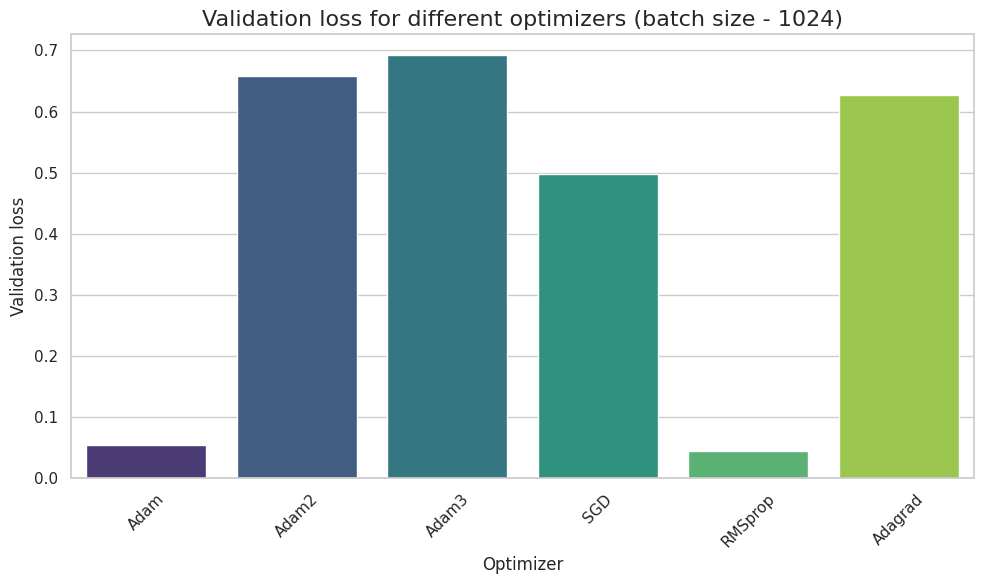

<ipython-input-62-6b0b0de4aefc>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')


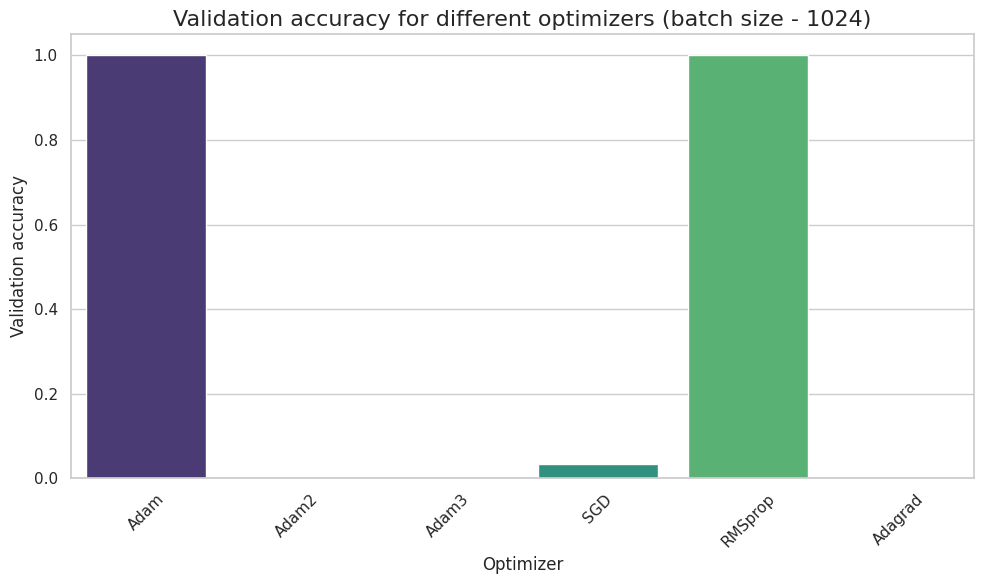

In [62]:
results_df['Optimizer'] = results_df['Optimizer'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Loss', palette='viridis')
plt.title('Validation loss for different optimizers (batch size - 1024)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation loss', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Optimizer', y='Validation Accuracy', palette='viridis')
plt.title('Validation accuracy for different optimizers (batch size - 1024)', fontsize=16)
plt.xlabel('Optimizer', fontsize=12)
plt.ylabel('Validation accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
#ChatGPT was used for code optimization and debugging.